<a href="https://colab.research.google.com/github/rmhanna/Randa/blob/main/Copy_of_Notebook7_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AAI614: Data Science & its Applications

*Notebook 7.2: Accelerating Data Science*

<a href="https://colab.research.google.com/github/harmanani/AAI614/blob/main/Week%207/Notebook7.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Source: Data Science with Python and Dask

### Examining the Metadata of Dask Objects

You would need for this lab to downlaod the data and store on your local disk as it is arond 2GB with 42.3M Rows of Parking Ticket Data.  The data can be downloaded from [Kaggle](http://www.kaggle.com/new-york-city/nyc-parking-tickets/)

In [ ]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("new-york-city/nyc-parking-tickets")

#print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nyc-parking-tickets' dataset.
Path to dataset files: /kaggle/input/nyc-parking-tickets


In [ ]:
display(df_dropped.dtypes)

,0
Summons Number,int64
Plate ID,string[pyarrow]
Registration State,string[pyarrow]
Plate Type,string[pyarrow]
Issue Date,string[pyarrow]
Violation Code,int64
Vehicle Body Type,string[pyarrow]
Vehicle Make,string[pyarrow]
Issuing Agency,string[pyarrow]
Street Code1,int64


In [ ]:
display(df_dropped.head())

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Feet From Curb,Violation Post Code,Violation Description
0,5092469481,GZH7067,NY,PAS,07/10/2016,7,SUBN,TOYOT,V,0,...,1111,D,<NA>,<NA>,<NA>,GY,2001,0,<NA>,FAILURE TO STOP AT RED LIGHT
1,5092451658,GZH7067,NY,PAS,07/08/2016,7,SUBN,TOYOT,V,0,...,1111,D,<NA>,<NA>,<NA>,GY,2001,0,<NA>,FAILURE TO STOP AT RED LIGHT
2,4006265037,FZX9232,NY,PAS,08/23/2016,5,SUBN,FORD,V,0,...,1111,C,<NA>,<NA>,<NA>,BK,2004,0,<NA>,BUS LANE VIOLATION
3,8478629828,66623ME,NY,COM,06/14/2017,47,REFG,MITSU,T,10610,...,408,l2,Y,0700A,0700P,WH,2007,0,04,47-Double PKG-Midtown
4,7868300310,37033JV,NY,COM,11/21/2016,69,DELV,INTER,T,10510,...,408,h1,Y,0700A,0700P,WHITE,2007,0,31 6,69-Failure to Disp Muni Recpt


In [ ]:
print(f"Original DataFrame shape: {df.shape}")
print(f"Dropped DataFrame shape: {df_dropped.shape}")

Original DataFrame shape: (<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(951c72c)).size() // 43, dtype=int64>, 43)
Dropped DataFrame shape: (<dask_expr.expr.Scalar: expr=FromGraph(77f7583).size() // 35, dtype=int64>, 35)


In [ ]:
import os

# The path to the dataset files was stored in the 'path' variable after the download.
# If you've restarted the notebook or the variable is not available, you can use the hardcoded path:
# dataset_path = '/root/.cache/kagglehub/datasets/new-york-city/nyc-parking-tickets/versions/2'

display(os.listdir(path))


['Parking_Violations_Issued_-_Fiscal_Year_2017.csv',
 'Parking_Violations_Issued_-_Fiscal_Year_2016.csv',
 'Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv',
 'Parking_Violations_Issued_-_Fiscal_Year_2015.csv']

In [ ]:
import os
print(os.path.join(path, 'Parking_Violations_Issued_-_Fiscal_Year_2017.csv'))

/kaggle/input/nyc-parking-tickets/Parking_Violations_Issued_-_Fiscal_Year_2017.csv


In [ ]:
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
from matplotlib import pyplot as plt
import os

# Specify dtypes for problematic columns
df = dd.read_csv(os.path.join(path, 'Parking_Violations_Issued_-_Fiscal_Year_2017.csv'),
                  dtype={'House Number': 'object', 'Time First Observed': 'object'})
df

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Time First Observed,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Intersecting Street,Date First Observed,Law Section,Sub Division,Violation Legal Code,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation
npartitions=32,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,string,string,string,string,int64,string,string,string,int64,int64,int64,int64,float64,int64,int64,int64,string,string,string,string,string,string,string,string,string,int64,int64,string,string,string,string,string,string,float64,int64,string,int64,string,string,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [ ]:
empty_columns = missing_count_pct[missing_count_pct == 100].index.tolist()
print(f"Columns that are 100% empty and will be dropped: {empty_columns}")

with ProgressBar():
    df_filtered_empty = df.drop(columns=empty_columns, axis=1).persist()

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered (non-empty columns only) DataFrame shape: {df_filtered_empty.shape}")

Columns that are 100% empty and will be dropped: ['No Standing or Stopping Violation', 'Hydrant Violation', 'Double Parking Violation']
[#######                                 ] | 18% Completed | 30.13 s

/usr/local/lib/python3.12/dist-packages/dask/dataframe/io/csv.py:77: DtypeWarning: Columns (18,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = reader(bio, **kwargs)


[####################################    ] | 90% Completed | 127.16 s

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[########################################] | 100% Completed | 137.21 s
Original DataFrame shape: (<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(951c72c)).size() // 43, dtype=int64>, 43)
Filtered (non-empty columns only) DataFrame shape: (<dask_expr.expr.Scalar: expr=FromGraph(efa0c87).size() // 40, dtype=int64>, 40)


In [ ]:
with ProgressBar():
    summary_statistics_df = df.describe().compute()
display(summary_statistics_df)

[################                        ] | 42% Completed | 51.08 s

/usr/local/lib/python3.12/dist-packages/dask/dataframe/io/csv.py:77: DtypeWarning: Columns (18,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = reader(bio, **kwargs)


[####################################### ] | 98% Completed | 105.10 s

/usr/local/lib/python3.12/dist-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


[########################################] | 100% Completed | 105.30 s


/usr/local/lib/python3.12/dist-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/usr/local/lib/python3.12/dist-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


,Summons Number,Violation Code,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Date First Observed,Law Section,Unregistered Vehicle?,Vehicle Year,Feet From Curb,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation
count,1.080303e+07,1.080303e+07,1.080303e+07,1.080303e+07,1.080303e+07,1.080303e+07,8.730628e+06,1.080303e+07,1.080303e+07,1.080303e+07,1.080303e+07,1.080303e+07,1127596.0,1.080303e+07,1.080303e+07,0.0,0.0,0.0
mean,6.817447e+09,3.459943e+01,2.386658e+04,2.031056e+04,2.034464e+04,2.443571e+07,5.569676e+01,4.501216e+01,4.682931e+01,3.367644e+05,4.508346e+05,5.511725e+02,0.0,1.578155e+03,1.200056e-01,NaN,NaN,NaN
std,2.320234e+09,1.935987e+01,2.266690e+04,2.194577e+04,2.201347e+04,2.604802e+07,3.794433e+01,4.055256e+01,6.266704e+01,2.253806e+05,2.981223e+06,2.950681e+02,0.0,8.255067e+02,8.288494e-01,NaN,NaN,NaN
min,1.002885e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,NaN,NaN,NaN
25%,5.093382e+09,2.000000e+01,5.880000e+03,0.000000e+00,0.000000e+00,2.016091e+07,1.900000e+01,9.000000e+00,5.000000e+00,3.454850e+05,0.000000e+00,4.080000e+02,0.0,2.002000e+03,0.000000e+00,NaN,NaN,NaN
50%,8.134535e+09,3.600000e+01,1.823000e+04,1.408000e+04,1.413000e+04,2.017091e+07,5.200000e+01,3.400000e+01,3.000000e+01,3.582120e+05,0.000000e+00,4.080000e+02,0.0,2.009000e+03,0.000000e+00,NaN,NaN,NaN
75%,8.487356e+09,4.000000e+01,3.559000e+04,3.411000e+04,3.415000e+04,2.018073e+07,9.000000e+01,7.900000e+01,7.900000e+01,3.631410e+05,0.000000e+00,1.111000e+03,0.0,2.014000e+03,0.000000e+00,NaN,NaN,NaN
max,8.585600e+09,9.900000e+01,9.802000e+04,9.831000e+04,9.828000e+04,8.888889e+07,9.330000e+02,9.330000e+02,9.970000e+02,9.999920e+05,2.022061e+07,6.408000e+03,0.0,2.069000e+03,1.600000e+01,NaN,NaN,NaN


In [ ]:
display(df.head())

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation
0,5092469481,GZH7067,NY,PAS,07/10/2016,7,SUBN,TOYOT,V,0,...,GY,NaN,2001,<NA>,0,<NA>,FAILURE TO STOP AT RED LIGHT,NaN,NaN,NaN
1,5092451658,GZH7067,NY,PAS,07/08/2016,7,SUBN,TOYOT,V,0,...,GY,NaN,2001,<NA>,0,<NA>,FAILURE TO STOP AT RED LIGHT,NaN,NaN,NaN
2,4006265037,FZX9232,NY,PAS,08/23/2016,5,SUBN,FORD,V,0,...,BK,NaN,2004,<NA>,0,<NA>,BUS LANE VIOLATION,NaN,NaN,NaN
3,8478629828,66623ME,NY,COM,06/14/2017,47,REFG,MITSU,T,10610,...,WH,NaN,2007,<NA>,0,04,47-Double PKG-Midtown,NaN,NaN,NaN
4,7868300310,37033JV,NY,COM,11/21/2016,69,DELV,INTER,T,10510,...,WHITE,NaN,2007,<NA>,0,31 6,69-Failure to Disp Muni Recpt,NaN,NaN,NaN


In [ ]:
missing_values = df.isnull().sum()
missing_values

Dask Series Structure:
npartitions=1
Date First Observed    int64
Violation Time           ...
Dask Name: sum, 5 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(951c72c)))).sum()

In [ ]:
missing_count = ((missing_values / df.index.size) * 100)
missing_count

Dask Series Structure:
npartitions=1
Date First Observed    float64
Violation Time             ...
Dask Name: mul, 9 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(951c72c)))).sum() / Index(frame=ArrowStringConversion(frame=FromMapProjectable(951c72c))).size() * 100

### Running Computations with the Compute Method

In [ ]:
with ProgressBar():
    missing_count_pct = missing_count.compute()
missing_count_pct

[#####################                   ] | 54% Completed | 77.96 s

/usr/local/lib/python3.12/dist-packages/dask/dataframe/io/csv.py:77: DtypeWarning: Columns (18,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = reader(bio, **kwargs)


[########################################] | 100% Completed | 124.89 s


,0
Summons Number,0.000000
Plate ID,0.006739
Registration State,0.000000
Plate Type,0.000000
Issue Date,0.000000
Violation Code,0.000000
Vehicle Body Type,0.395361
Vehicle Make,0.676199
Issuing Agency,0.000000
Street Code1,0.000000


In [ ]:
columns_to_drop = missing_count_pct[missing_count_pct > 60].index
with ProgressBar():
    df_dropped = df.drop(columns_to_drop.tolist(), axis=1).persist()

[#######                                 ] | 18% Completed | 25.96 s

/usr/local/lib/python3.12/dist-packages/dask/dataframe/io/csv.py:77: DtypeWarning: Columns (18,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = reader(bio, **kwargs)


[########################################] | 100% Completed | 125.73 s


### Visualizing a Simple DAG using Dask Delayed Objects

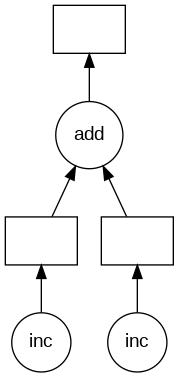

In [ ]:
import dask.delayed as delayed
from dask.diagnostics import ProgressBar

def inc(i):
    return i + 1

def add(x, y):
    return x + y

x = delayed(inc)(1)
y = delayed(inc)(2)
z = delayed(add)(x, y)

z.visualize()

### Visualizing More Complex DAGs with Loops and Collections

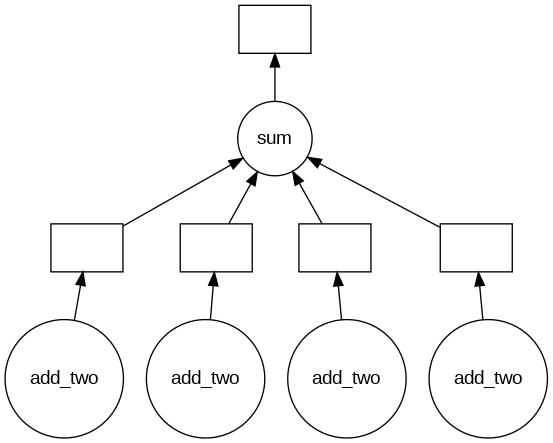

In [ ]:
# Listing 2.7
def add_two(x):
    return x + 2

def sum_two_numbers(x,y):
    return x + y

def multiply_four(x):
    return x * 4

data = [1, 5, 8, 10]

step1 = [delayed(add_two)(i) for i in data]
total = delayed(sum)(step1)
total.visualize()

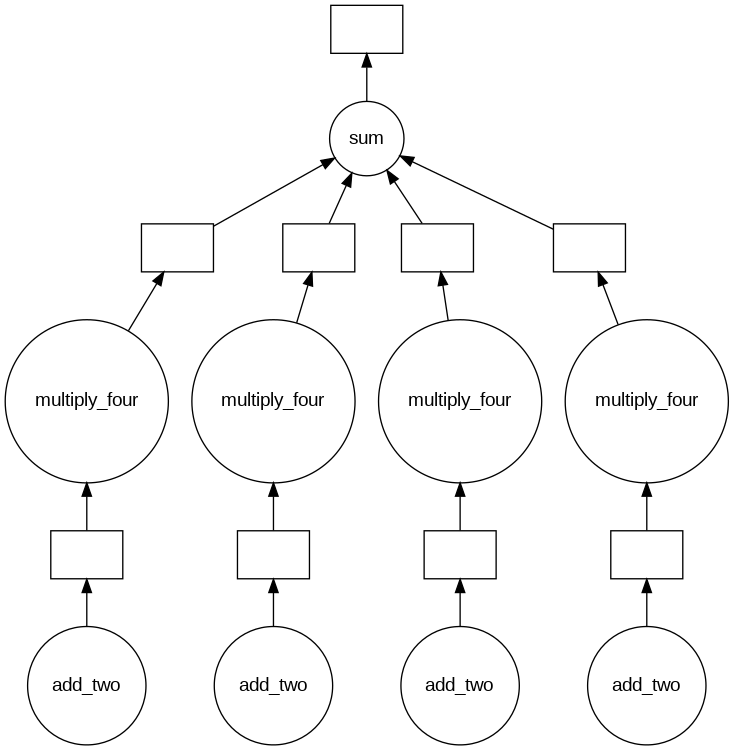

In [ ]:
def add_two(x):
    return x + 2

def sum_two_numbers(x,y):
    return x + y

def multiply_four(x):
    return x * 4

data = [1, 5, 8, 10]

step1 = [delayed(add_two)(i) for i in data]
step2 = [delayed(multiply_four)(j) for j in step1]
total = delayed(sum)(step2)
total.visualize()

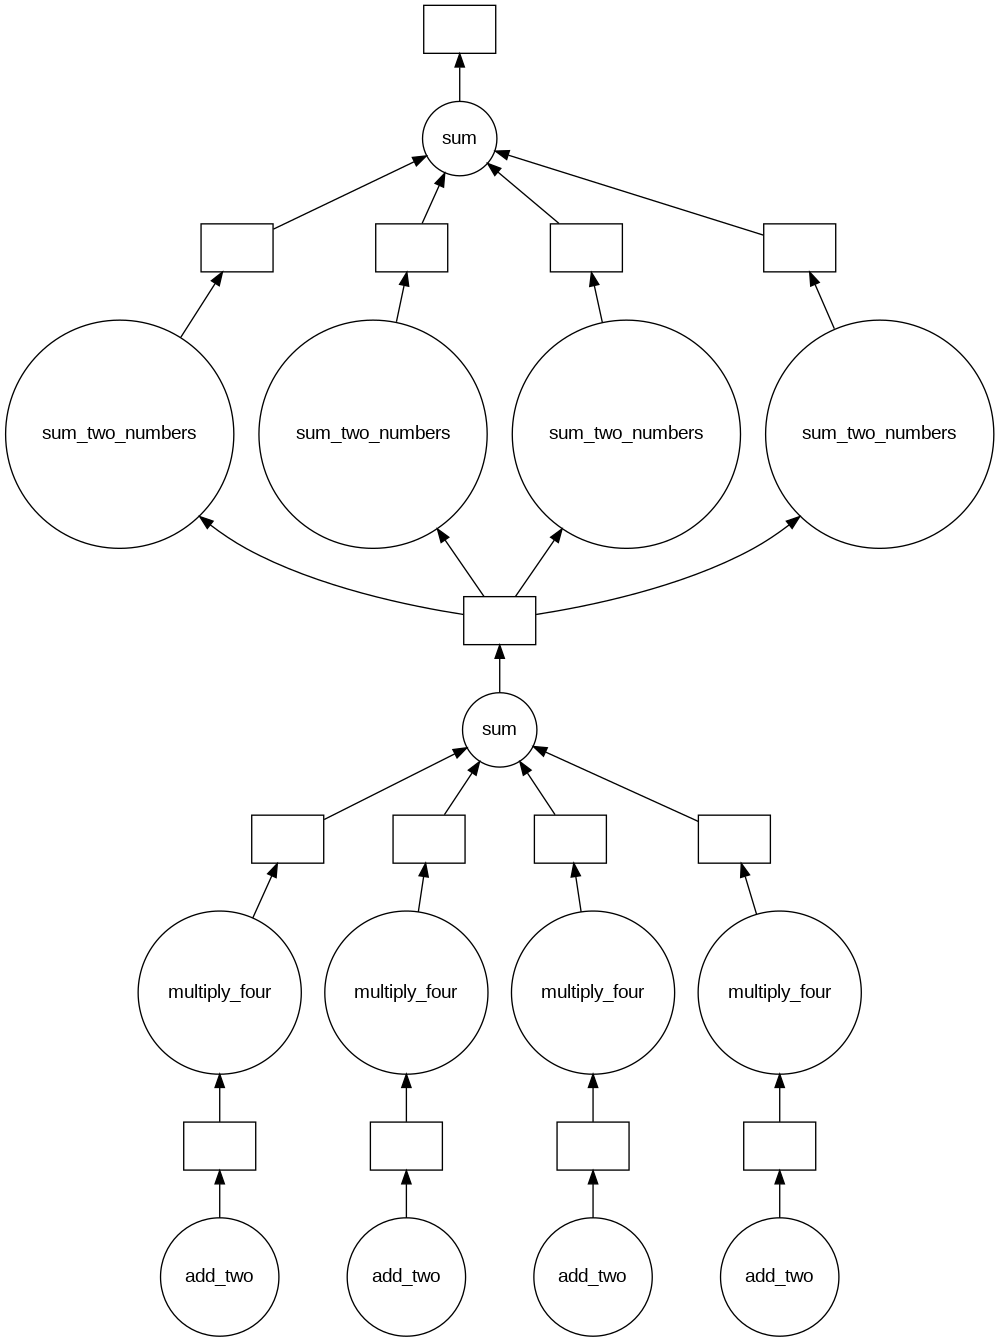

In [ ]:
data2 = [delayed(sum_two_numbers)(k, total) for k in data]
total2 = delayed(sum)(data2)
total2.visualize()

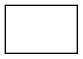

In [ ]:
total_persisted = total.persist()
total_persisted.visualize()

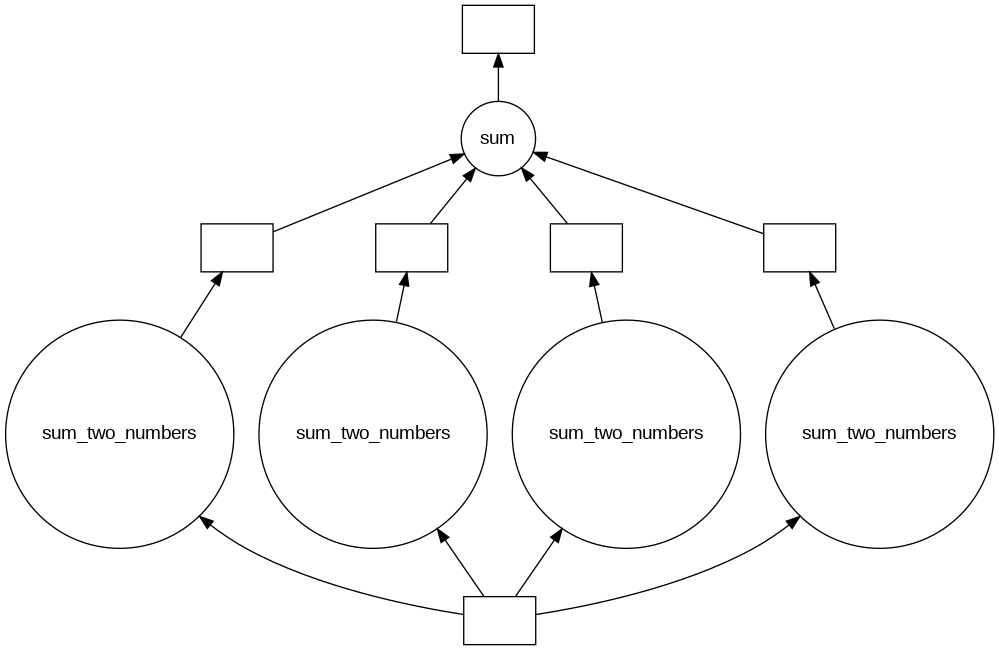

In [ ]:
data2 = [delayed(sum_two_numbers)(l, total_persisted) for l in data]
total2 = delayed(sum)(data2)
total2.visualize()

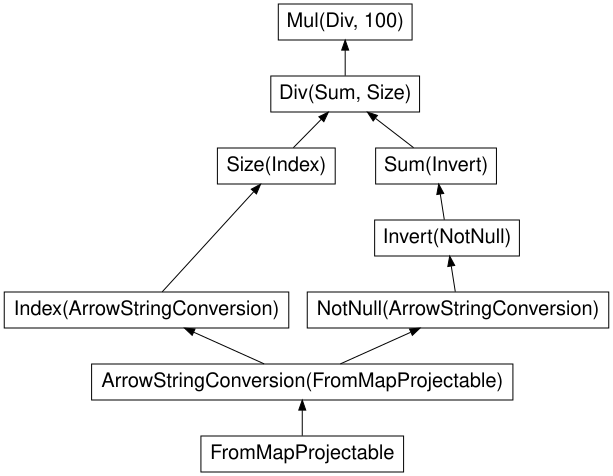

In [ ]:
missing_count.visualize()